# 🔬 Single Image Test — Line Segmentation Pipeline
### Drop one prescription image → see the output at every step visually

This notebook tests the **already trained models** on a single new image.
It shows you what happens at each stage so you can verify quality before connecting to HTR.

---
## ⚙️ CELL 0 — Configuration
**Only edit the values in this cell. Nothing else needs to change.**

In [118]:
import os

# ─────────────────────────────────────────────────────────────
# 1. YOUR PROJECT ROOT (same as the main pipeline notebook)
# ─────────────────────────────────────────────────────────────
PROJECT_ROOT = "/Users/avishkashenan/Desktop/Line Segmentation New"

# ─────────────────────────────────────────────────────────────
# 2. THE IMAGE YOU WANT TO TEST
#    Drop any prescription photo here — full path to the file
# ─────────────────────────────────────────────────────────────
TEST_IMAGE_PATH = "/Users/avishkashenan/Desktop/Line Segmentation New/data/raw_images/177464_2.Jpg"
#                  ↑ Change this to the actual image you want to test

# ─────────────────────────────────────────────────────────────
# 3. ROI CROP SETTINGS (same values you used in main pipeline)
# ─────────────────────────────────────────────────────────────
TOP_PCT    = 0.25   # how much to cut from top (doctor header)
BOTTOM_PCT = 0.20   # how much to cut from bottom (footer)

# ─────────────────────────────────────────────────────────────
# 4. CRAFT merge threshold
# ─────────────────────────────────────────────────────────────
MERGE_THRESHOLD = 45  # increase if lines split too much, decrease if they merge

# ── Auto-resolved paths (don't change these) ─────────────────
DEEPLAB_MODEL = os.path.join(PROJECT_ROOT, "models", "deeplab_medicine_detector.pth")
CRAFT_MODEL   = os.path.join(PROJECT_ROOT, "models", "craft_mlt_25k.pth")
CRAFT_REPO    = os.path.join(PROJECT_ROOT, "libs", "CRAFT-pytorch")
OUTPUT_DIR    = os.path.join(PROJECT_ROOT, "data", "test_output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Validation checks ────────────────────────────────────────
checks = {
    "Test image":      TEST_IMAGE_PATH,
    "DeepLab model":   DEEPLAB_MODEL,
    "CRAFT model":     CRAFT_MODEL,
    "CRAFT repo":      CRAFT_REPO,
}
all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status}  {name}: {path}")
    if not exists:
        all_ok = False

print()
if all_ok:
    print("All files found! Ready to run.")
else:
    print("⚠️  Fix the missing paths above before continuing.")

  ✅  Test image: /Users/avishkashenan/Desktop/Line Segmentation New/data/raw_images/177464_2.Jpg
  ✅  DeepLab model: /Users/avishkashenan/Desktop/Line Segmentation New/models/deeplab_medicine_detector.pth
  ✅  CRAFT model: /Users/avishkashenan/Desktop/Line Segmentation New/models/craft_mlt_25k.pth
  ✅  CRAFT repo: /Users/avishkashenan/Desktop/Line Segmentation New/libs/CRAFT-pytorch

All files found! Ready to run.


---
## 📌 STAGE 1 — Load & Show Original Image

Image loaded: 177464_2.Jpg
Size: 2592 x 1944 pixels


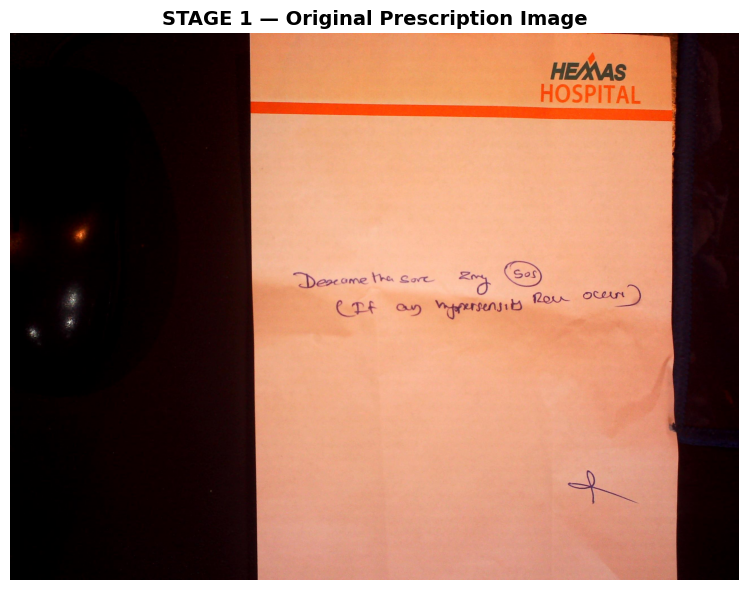

In [119]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show(img, title="", bgr=True, figsize=(12, 6)):
    """Helper: display an image inline with a title."""
    if bgr and len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Load original
original = cv2.imread(TEST_IMAGE_PATH)
if original is None:
    raise FileNotFoundError(f"Cannot read image: {TEST_IMAGE_PATH}")

h, w = original.shape[:2]
print(f"Image loaded: {os.path.basename(TEST_IMAGE_PATH)}")
print(f"Size: {w} x {h} pixels")

show(original, "STAGE 1 — Original Prescription Image")

---
## 📌 STAGE 2 — Preprocessing (Deskew + Threshold)

Skew angle detected and corrected: -45.50°


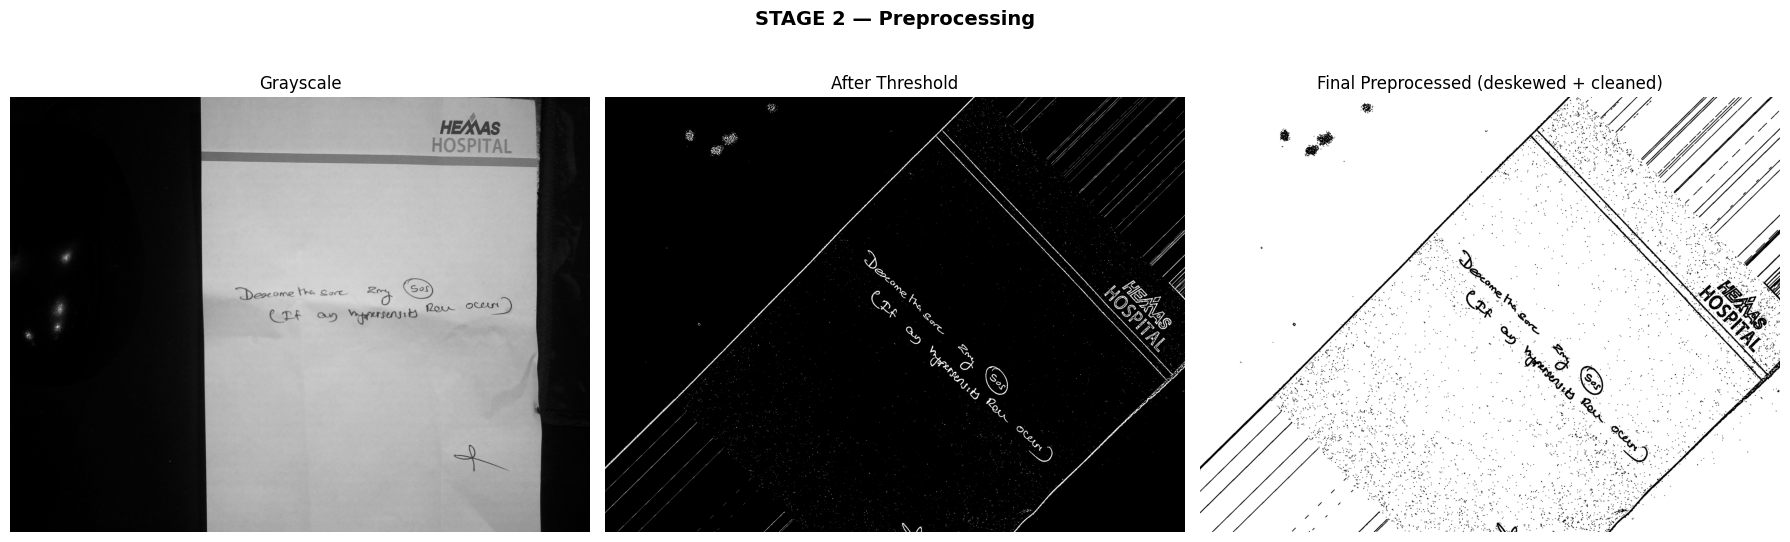

Saved: stage2_preprocessing.jpg


In [120]:
def deskew_image(gray):
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)
    angle = 0.0
    if lines is not None:
        angles = [(t * 180 / np.pi) - 90 for _, t in lines[:, 0]]
        angle  = np.median(angles)
        h, w   = gray.shape
        M      = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        gray   = cv2.warpAffine(gray, M, (w, h),
                                 flags=cv2.INTER_CUBIC,
                                 borderMode=cv2.BORDER_REPLICATE)
    return gray, angle

# Preprocessing pipeline
gray            = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
deskewed, angle = deskew_image(gray)
thresh          = cv2.adaptiveThreshold(deskewed, 255,
                      cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                      cv2.THRESH_BINARY_INV, 15, 5)
dilated         = cv2.dilate(thresh, np.ones((3, 3), np.uint8), iterations=1)
preprocessed    = cv2.bitwise_not(dilated)

print(f"Skew angle detected and corrected: {angle:.2f}°")

# Show side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gray,         cmap='gray'); axes[0].set_title('Grayscale');       axes[0].axis('off')
axes[1].imshow(thresh,       cmap='gray'); axes[1].set_title('After Threshold'); axes[1].axis('off')
axes[2].imshow(preprocessed, cmap='gray'); axes[2].set_title('Final Preprocessed (deskewed + cleaned)'); axes[2].axis('off')
plt.suptitle('STAGE 2 — Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage2_preprocessing.jpg'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: stage2_preprocessing.jpg")

---
## 📌 STAGE 3 — ROI Extraction (Remove Header/Footer)

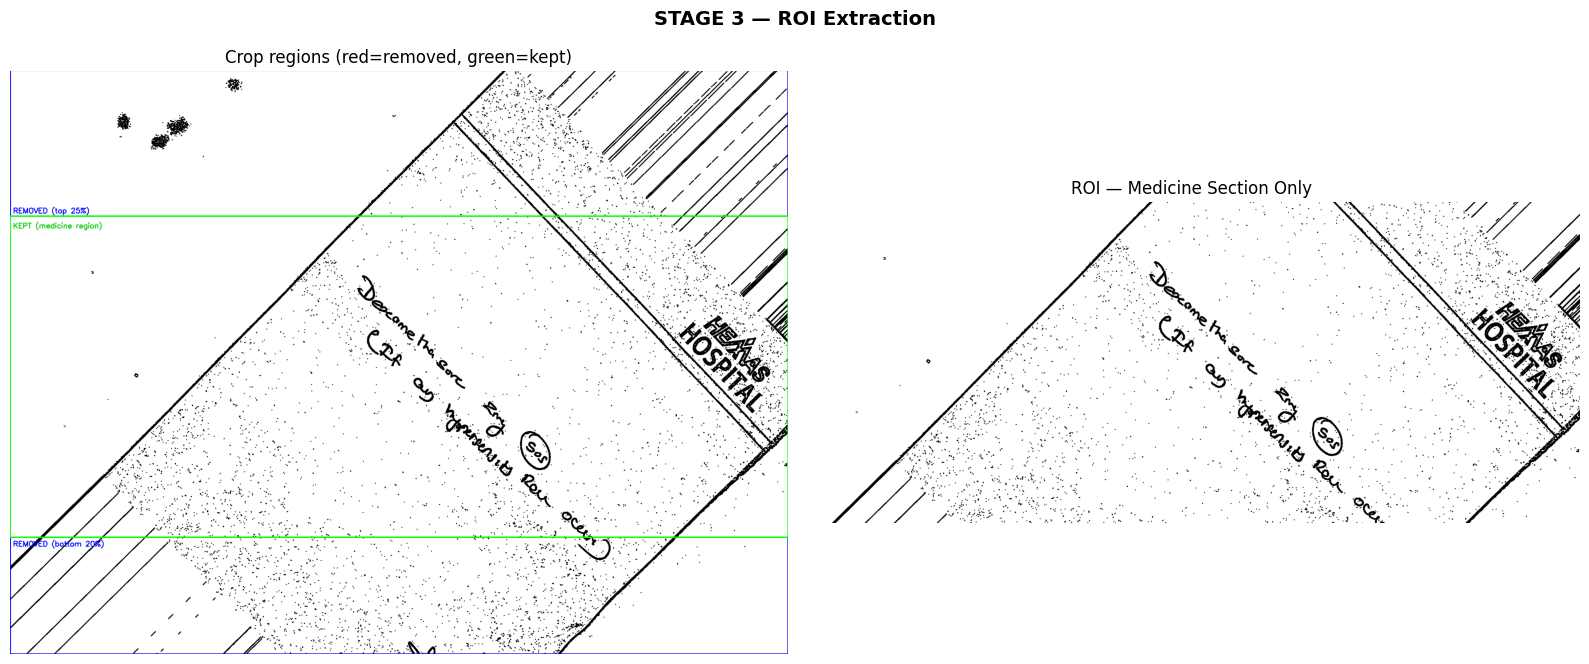

ROI size: 2592 x 1069 pixels
Saved: stage3_roi.jpg


In [121]:
h, w   = preprocessed.shape[:2]
start_y = int(h * TOP_PCT)
end_y   = int(h * (1.0 - BOTTOM_PCT))
roi     = preprocessed[start_y:end_y, 0:w]

# Show the crop region on original
annotated = cv2.cvtColor(preprocessed.copy(), cv2.COLOR_GRAY2BGR)
cv2.rectangle(annotated, (0, 0),       (w, start_y), (255, 0, 0), 3)   # header (red)
cv2.rectangle(annotated, (0, end_y),   (w, h),       (255, 0, 0), 3)   # footer (red)
cv2.rectangle(annotated, (0, start_y), (w, end_y),   (0, 255, 0), 3)   # kept region (green)
cv2.putText(annotated, f"REMOVED (top {int(TOP_PCT*100)}%)",    (10, start_y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)
cv2.putText(annotated, "KEPT (medicine region)", (10, start_y+40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,200,0), 2)
cv2.putText(annotated, f"REMOVED (bottom {int(BOTTOM_PCT*100)}%)", (10, end_y+30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[0].set_title('Crop regions (red=removed, green=kept)')
axes[0].axis('off')
axes[1].imshow(roi, cmap='gray')
axes[1].set_title('ROI — Medicine Section Only')
axes[1].axis('off')
plt.suptitle('STAGE 3 — ROI Extraction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage3_roi.jpg'), dpi=150, bbox_inches='tight')
plt.show()
print(f"ROI size: {roi.shape[1]} x {roi.shape[0]} pixels")
print(f"Saved: stage3_roi.jpg")

---
## 📌 STAGE 4 — DeepLab Inference (Isolate Medicine Region)

Using Apple Silicon MPS
Loading DeepLab model...
DeepLab model loaded!


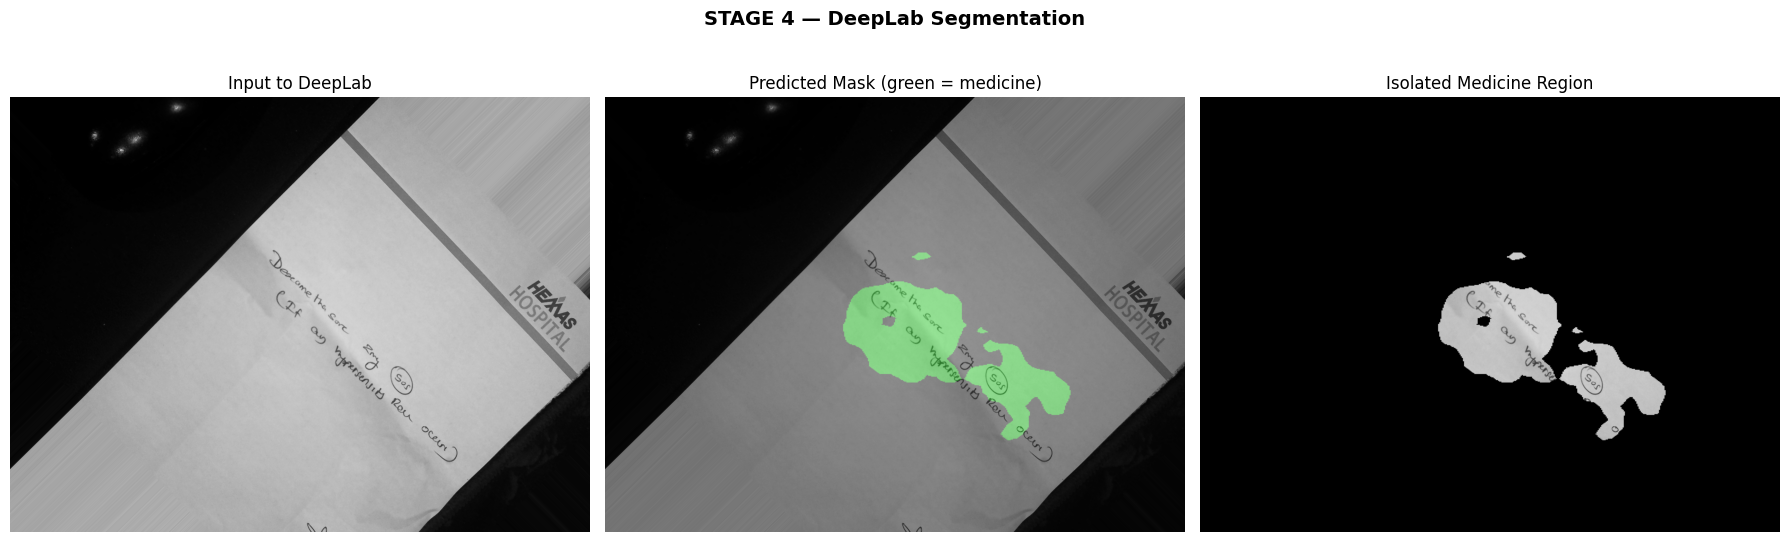

Medicine region: 5.6% of image
Saved: stage4_deeplab.jpg


In [122]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50

# Hardware
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon MPS")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Load model
print("Loading DeepLab model...")
model = deeplabv3_resnet50(weights=None, aux_loss=True)
model.classifier[4]     = nn.Conv2d(256, 2, kernel_size=(1,1))
if model.aux_classifier:
    model.aux_classifier[4] = nn.Conv2d(256, 2, kernel_size=(1,1))
model.load_state_dict(torch.load(DEEPLAB_MODEL, map_location=device))
model.to(device)
model.eval()
print("DeepLab model loaded!")

# Prepare image — use the COLOR preprocessed image for DeepLab
# We rebuild it from original to keep color channels
gray_deskewed, _ = deskew_image(cv2.cvtColor(original, cv2.COLOR_BGR2GRAY))
preprocessed_bgr = cv2.cvtColor(gray_deskewed, cv2.COLOR_GRAY2BGR)
orig_h, orig_w   = preprocessed_bgr.shape[:2]

transform   = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_rgb     = cv2.cvtColor(preprocessed_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (512, 512))
tensor      = transform(img_resized).unsqueeze(0).to(device)

# Run inference
with torch.no_grad():
    out  = model(tensor)['out'][0]
    mask = out.argmax(0).byte().cpu().numpy()

# Scale mask back to original size
full_mask = cv2.resize(mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
isolated  = cv2.bitwise_and(preprocessed_bgr, preprocessed_bgr, mask=full_mask)

# Visualize
mask_colored = np.zeros_like(preprocessed_bgr)
mask_colored[full_mask == 1] = [0, 255, 0]  # green = medicine region
overlay = cv2.addWeighted(preprocessed_bgr, 0.7, mask_colored, 0.3, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(preprocessed_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input to DeepLab')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Predicted Mask (green = medicine)')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB))
axes[2].set_title('Isolated Medicine Region')
axes[2].axis('off')
plt.suptitle('STAGE 4 — DeepLab Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage4_deeplab.jpg'), dpi=150, bbox_inches='tight')
plt.show()

medicine_pixels = int(full_mask.sum())
total_pixels    = full_mask.size
print(f"Medicine region: {medicine_pixels/total_pixels*100:.1f}% of image")
print(f"Saved: stage4_deeplab.jpg")

---
## 📌 STAGE 5 — CRAFT Line Detection & Segmentation

In [123]:
import sys
from collections import OrderedDict
from torch.autograd import Variable

# CRAFT compatibility fix
import torchvision.models.vgg as vgg
if not hasattr(vgg, 'model_urls'):
    vgg.model_urls = {'vgg16_bn': 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'}

if CRAFT_REPO not in sys.path:
    sys.path.append(CRAFT_REPO)

from craft import CRAFT
import craft_utils
import imgproc

def copyStateDict(state_dict):
    start = 1 if list(state_dict.keys())[0].startswith("module") else 0
    return OrderedDict({".".join(k.split(".")[start:]): v for k, v in state_dict.items()})

def merge_polygons(polys, threshold=45):
    if polys is None or len(polys) == 0: return []
    rects = sorted([list(cv2.boundingRect(np.array(p, dtype=np.float32))) for p in polys], key=lambda b: b[1])
    lines, cur = [], [rects[0]]
    for r in rects[1:]:
        if abs(r[1] - cur[-1][1]) < cur[-1][3] * 0.5: cur.append(r)
        else: lines.append(cur); cur = [r]
    lines.append(cur)
    merged = []
    for line in lines:
        line.sort(key=lambda b: b[0])
        box = line[0]
        for nb in line[1:]:
            if nb[0] - (box[0]+box[2]) < threshold:
                box = [box[0], min(box[1],nb[1]), (nb[0]+nb[2])-box[0], max(box[1]+box[3],nb[1]+nb[3])-min(box[1],nb[1])]
            else: merged.append(box); box = nb
        merged.append(box)
    return [[[x,y],[x+w,y],[x+w,y+h],[x,y+h]] for x,y,w,h in merged]

def crop_warp(img, poly):
    pts = np.array(poly, dtype=np.float32)
    mw  = int(max(np.linalg.norm(pts[0]-pts[1]), np.linalg.norm(pts[3]-pts[2])))
    mh  = int(max(np.linalg.norm(pts[0]-pts[3]), np.linalg.norm(pts[1]-pts[2])))
    if mw == 0 or mh == 0: return None
    dst = np.array([[0,0],[mw-1,0],[mw-1,mh-1],[0,mh-1]], dtype="float32")
    return cv2.warpPerspective(img, cv2.getPerspectiveTransform(pts, dst), (mw, mh))

def pad_to_size(img, tw=128, th=32):
    if img is None or img.size == 0: return None
    h, w = img.shape[:2]
    if h == 0 or w == 0: return None
    s   = min(tw/w, th/h)
    nw, nh = max(1,int(w*s)), max(1,int(h*s))
    res = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    out = np.ones((th, tw, 3) if len(img.shape)==3 else (th, tw), dtype=np.uint8)*255
    yo  = (th-nh)//2
    if len(img.shape)==3: out[yo:yo+nh, 0:nw, :] = res
    else: out[yo:yo+nh, 0:nw] = res
    return out

# ── Load CRAFT ────────────────────────────────────────────────
print("Loading CRAFT model...")
craft_device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
net = CRAFT()
net.load_state_dict(copyStateDict(torch.load(CRAFT_MODEL, map_location='cpu')))
net = net.to(craft_device)
net.eval()
print(f"CRAFT loaded on: {craft_device}")

# ── Run CRAFT on isolated image ───────────────────────────────
params = {'text_threshold':0.7, 'link_threshold':0.4, 'low_text':0.4,
          'poly':False, 'canvas_size':1280, 'mag_ratio':1.5}

iso_rgb = cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB)
img_res, ratio, _ = imgproc.resize_aspect_ratio(iso_rgb, params['canvas_size'],
                        interpolation=cv2.INTER_LINEAR, mag_ratio=params['mag_ratio'])
rh = rw = 1 / ratio
x  = imgproc.normalizeMeanVariance(img_res)
x  = Variable(torch.from_numpy(x).permute(2,0,1).unsqueeze(0)).to(craft_device)

with torch.no_grad():
    y, _ = net(x)

score_text = y[0,:,:,0].cpu().numpy()
score_link = y[0,:,:,1].cpu().numpy()
boxes, polys = craft_utils.getDetBoxes(score_text, score_link,
    params['text_threshold'], params['link_threshold'], params['low_text'], params['poly'])
boxes  = craft_utils.adjustResultCoordinates(boxes, rw, rh)
polys  = craft_utils.adjustResultCoordinates(polys, rw, rh)
for k in range(len(polys)):
    if polys[k] is None: polys[k] = boxes[k]

merged_polys = merge_polygons(polys, MERGE_THRESHOLD)
merged_polys = sorted(merged_polys, key=lambda p: (p[0][1], p[0][0]))

print(f"Raw detections: {len(polys)}")
print(f"After merging:  {len(merged_polys)} lines")

Loading CRAFT model...


/Users/avishkashenan/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/avishkashenan/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


CRAFT loaded on: mps
Raw detections: 4
After merging:  4 lines


---
## 📌 STAGE 6 — Visualize Detected Lines on Image

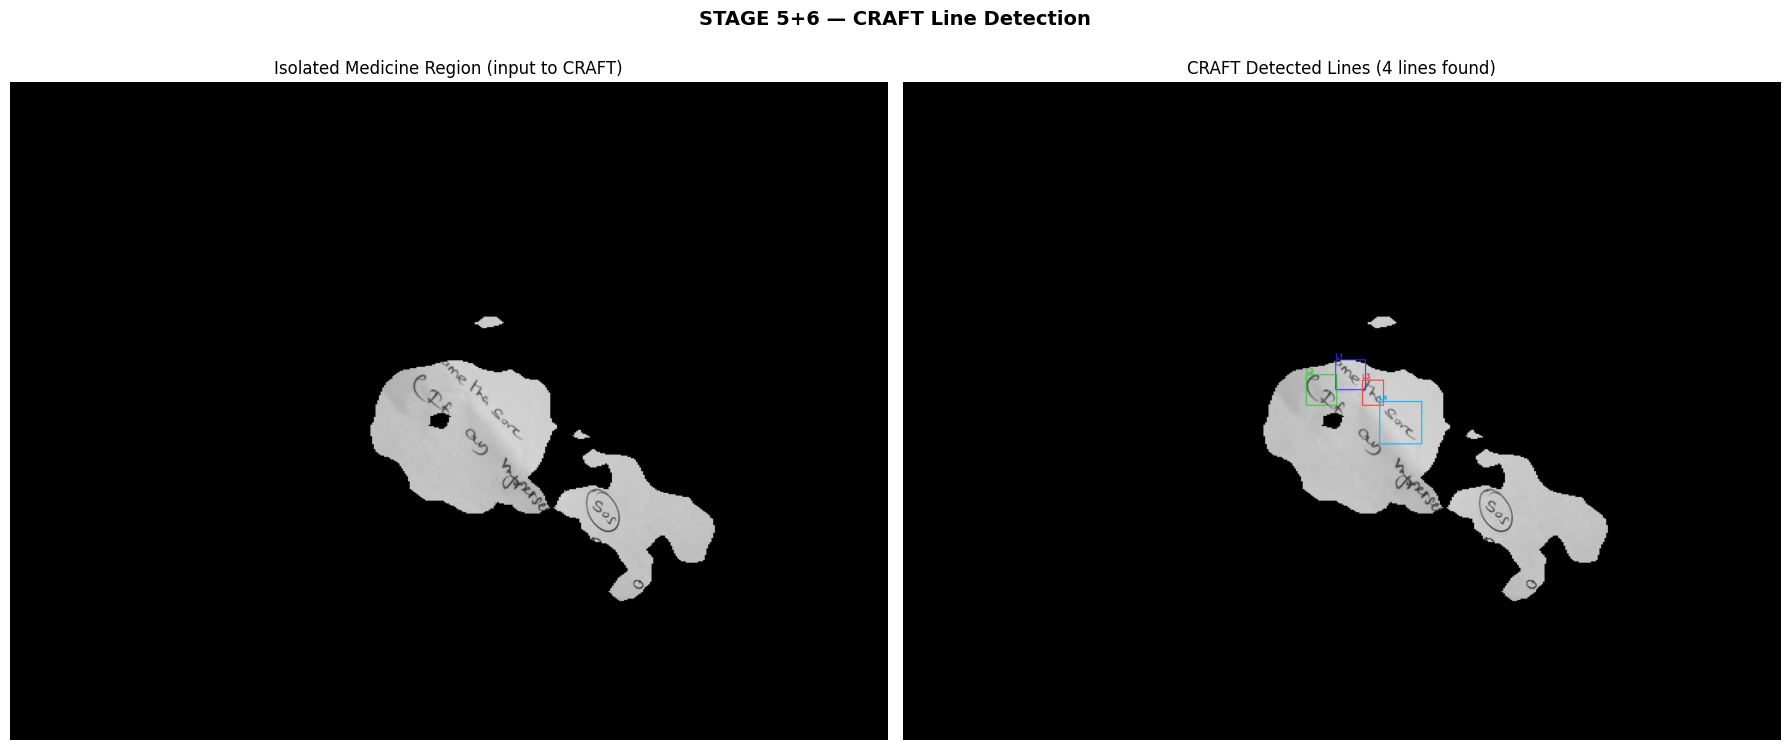

Found 4 medicine lines
Saved: stage5_craft_detection.jpg


In [124]:
# Draw all detected line boxes on the image
viz = isolated.copy()
colors = [
    (255,  50,  50), (50, 200,  50), ( 50,  50, 255),
    (255, 180,   0), (180,  0, 255), (  0, 200, 200),
    (255, 100, 180), (100, 255, 100), (100, 100, 255),
    (200, 200,  50)
]

for i, poly in enumerate(merged_polys):
    pts   = np.array(poly, dtype=np.int32)
    color = colors[i % len(colors)]
    cv2.polylines(viz, [pts], True, color, 2)
    # Label each line
    x, y = pts[0]
    cv2.putText(viz, f"L{i+1}", (x, max(0, y-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB))
axes[0].set_title('Isolated Medicine Region (input to CRAFT)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'CRAFT Detected Lines ({len(merged_polys)} lines found)')
axes[1].axis('off')
plt.suptitle('STAGE 5+6 — CRAFT Line Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage5_craft_detection.jpg'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Found {len(merged_polys)} medicine lines")
print(f"Saved: stage5_craft_detection.jpg")

---
## 📌 STAGE 7 — Extract & Show Final 128×32 Line Crops
These are the exact images that will be passed to your HTR model.

Extracted 4 line crops (128×32 JPG)
Saved to: /Users/avishkashenan/Desktop/Line Segmentation New/data/test_output/line_crops


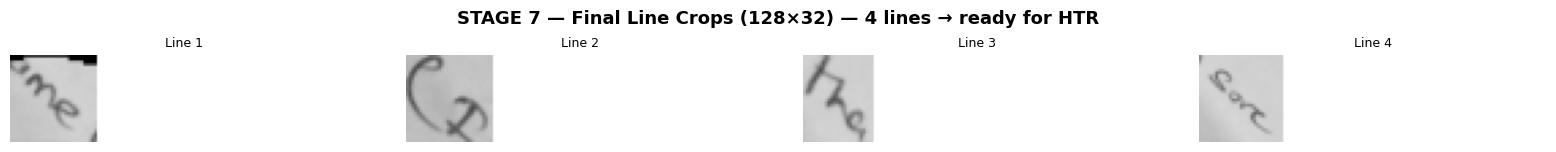

Saved: stage7_line_crops.jpg


In [125]:
# Extract all line crops
line_crops = []
line_names = []
base_name  = os.path.splitext(os.path.basename(TEST_IMAGE_PATH))[0]

crops_dir = os.path.join(OUTPUT_DIR, "line_crops")
os.makedirs(crops_dir, exist_ok=True)

for i, poly in enumerate(merged_polys):
    cropped    = crop_warp(isolated, poly)
    final_crop = pad_to_size(cropped, tw=128, th=32)
    if final_crop is None:
        continue
    fname = f"{base_name}_line_{i:03d}.jpg"
    cv2.imwrite(os.path.join(crops_dir, fname), final_crop)
    line_crops.append(final_crop)
    line_names.append(fname)

print(f"Extracted {len(line_crops)} line crops (128×32 JPG)")
print(f"Saved to: {crops_dir}")

# Display all line crops in a grid
n    = len(line_crops)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*1.5))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

for i, (crop, name) in enumerate(zip(line_crops, line_names)):
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    axes[i].imshow(rgb)
    axes[i].set_title(f"Line {i+1}", fontsize=9)
    axes[i].axis('off')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'STAGE 7 — Final Line Crops (128×32) — {n} lines → ready for HTR',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage7_line_crops.jpg'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: stage7_line_crops.jpg")

---
## 📌 STAGE 8 — Full Pipeline Summary (Side by Side)

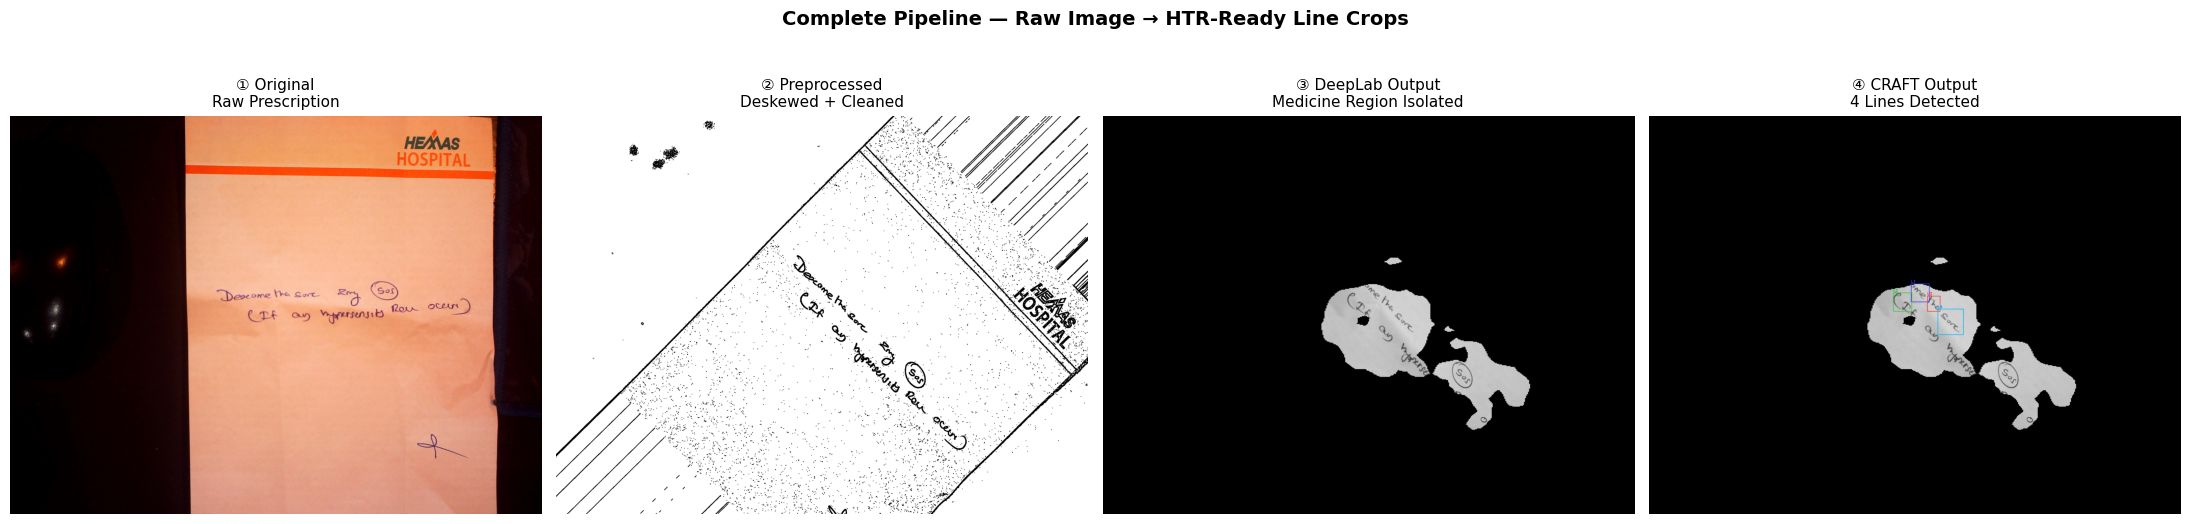

PIPELINE SUMMARY
  Input image      : 177464_2.Jpg
  Skew corrected   : -45.50°
  Lines detected   : 4
  Line crops saved : 4 × (128×32 JPG)
  Output folder    : /Users/avishkashenan/Desktop/Line Segmentation New/data/test_output

  ✅ These 4 images in line_crops/ are ready for your HTR model!


In [126]:
# Show the complete transformation in one figure
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('① Original\nRaw Prescription', fontsize=11)
axes[0].axis('off')

axes[1].imshow(preprocessed, cmap='gray')
axes[1].set_title('② Preprocessed\nDeskewed + Cleaned', fontsize=11)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB))
axes[2].set_title('③ DeepLab Output\nMedicine Region Isolated', fontsize=11)
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
axes[3].set_title(f'④ CRAFT Output\n{len(merged_polys)} Lines Detected', fontsize=11)
axes[3].axis('off')

plt.suptitle('Complete Pipeline — Raw Image → HTR-Ready Line Crops',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pipeline_summary.jpg'), dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("PIPELINE SUMMARY")
print("=" * 50)
print(f"  Input image      : {os.path.basename(TEST_IMAGE_PATH)}")
print(f"  Skew corrected   : {angle:.2f}°")
print(f"  Lines detected   : {len(merged_polys)}")
print(f"  Line crops saved : {len(line_crops)} × (128×32 JPG)")
print(f"  Output folder    : {OUTPUT_DIR}")
print("=" * 50)
print(f"\n  ✅ These {len(line_crops)} images in line_crops/ are ready for your HTR model!")

---
## 📌 How to Connect This to Your HTR Model

The cell below shows exactly how your HTR model should consume these outputs.
This is the **bridge code** between Part 1 (this pipeline) and Part 2 (HTR).

In [127]:
# ── HTR BRIDGE CODE ──────────────────────────────────────────
# Copy this into the START of your HTR notebook/script
# This is how HTR receives the line crops from this pipeline

import os
import cv2
import numpy as np
from pathlib import Path

# ── Option A: Test on a single new image (what this notebook does) ──
# line_crops come directly from the crops_dir variable above
single_image_crops = [
    (name, crop) 
    for name, crop in zip(line_names, line_crops)
]

print("HTR INPUT READY")
print(f"  Source image : {os.path.basename(TEST_IMAGE_PATH)}")
print(f"  Line crops   : {len(single_image_crops)}")
print(f"  Format       : 128×32 BGR numpy arrays\n")

# ── This is what your HTR model loop looks like ──────────────
print("Example HTR loop (replace 'your_htr_model.predict()' with your actual model):")
print("-" * 50)
for i, (name, crop_img) in enumerate(single_image_crops):
    # Convert to grayscale if your HTR model expects it
    gray_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)
    
    # Normalize to [0,1] float — common HTR input format
    normalized = gray_crop.astype(np.float32) / 255.0
    
    # Add batch + channel dimensions → shape: (1, 1, 32, 128)
    tensor_input = normalized[np.newaxis, np.newaxis, :, :]
    
    # ↓ Replace this with your actual HTR model call
    predicted_text = f"[HTR model output for line {i+1}]"
    
    print(f"  Line {i+1:02d} ({name}): {predicted_text}")

print("-" * 50)
print(f"\nYour HTR model receives each crop as:")
print(f"  • numpy array shape : (32, 128) grayscale")
print(f"  • or tensor shape   : (1, 1, 32, 128) normalized float")
print(f"  • file path         : {crops_dir}/<name>_line_NNN.jpg")

HTR INPUT READY
  Source image : 177464_2.Jpg
  Line crops   : 4
  Format       : 128×32 BGR numpy arrays

Example HTR loop (replace 'your_htr_model.predict()' with your actual model):
--------------------------------------------------
  Line 01 (177464_2_line_000.jpg): [HTR model output for line 1]
  Line 02 (177464_2_line_001.jpg): [HTR model output for line 2]
  Line 03 (177464_2_line_002.jpg): [HTR model output for line 3]
  Line 04 (177464_2_line_003.jpg): [HTR model output for line 4]
--------------------------------------------------

Your HTR model receives each crop as:
  • numpy array shape : (32, 128) grayscale
  • or tensor shape   : (1, 1, 32, 128) normalized float
  • file path         : /Users/avishkashenan/Desktop/Line Segmentation New/data/test_output/line_crops/<name>_line_NNN.jpg
